In [ ]:
# ==========================================
# 事前準備: 必要なライブラリのインストール (google colab で実行しない場合はコメントアウト)
# ==========================================
!pip install -q ultralytics

In [1]:
# ライブラリをインポート (ultralytics(yolo)はバージョンを表示)
import cv2
import urllib.request
import matplotlib.pyplot as plt
from ultralytics import YOLO
import ultralytics
print('ultralytics version:', ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\khiramatsu\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics version: 8.4.78


サンプル画像:


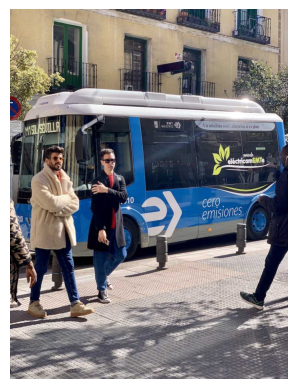

In [2]:
# ==========================================
# 0. サンプル画像のダウンロードと読み込み
# ==========================================
print("サンプル画像:")
image_url = "https://ultralytics.com/images/bus.jpg" # YOLO公式のサンプル画像
image_path = "sample.jpg"
urllib.request.urlretrieve(image_url, image_path)

# OpenCVで画像を読み込み、Matplotlib表示用に色空間をBGRからRGBに変換
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 読み込んだ画像を表示
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

【1】画像分類を実行中...

image 1/1 e:\sudspg\su_dspg_ds\ml11\sample.jpg: 224x224 minibus 0.50, police_van 0.29, trolleybus 0.05, golfcart 0.02, jinrikisha 0.02, 207.8ms
Speed: 43.1ms preprocess, 207.8ms inference, 0.7ms postprocess per image at shape (1, 3, 224, 224)
【2】物体認識を実行中...

image 1/1 e:\sudspg\su_dspg_ds\ml11\sample.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 62.8ms
Speed: 11.6ms preprocess, 62.8ms inference, 36.0ms postprocess per image at shape (1, 3, 640, 480)
【3】セグメンテーションを実行中...

image 1/1 e:\sudspg\su_dspg_ds\ml11\sample.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 111.5ms
Speed: 1.6ms preprocess, 111.5ms inference, 15.2ms postprocess per image at shape (1, 3, 640, 480)
処理が完了しました。結果を表示します。


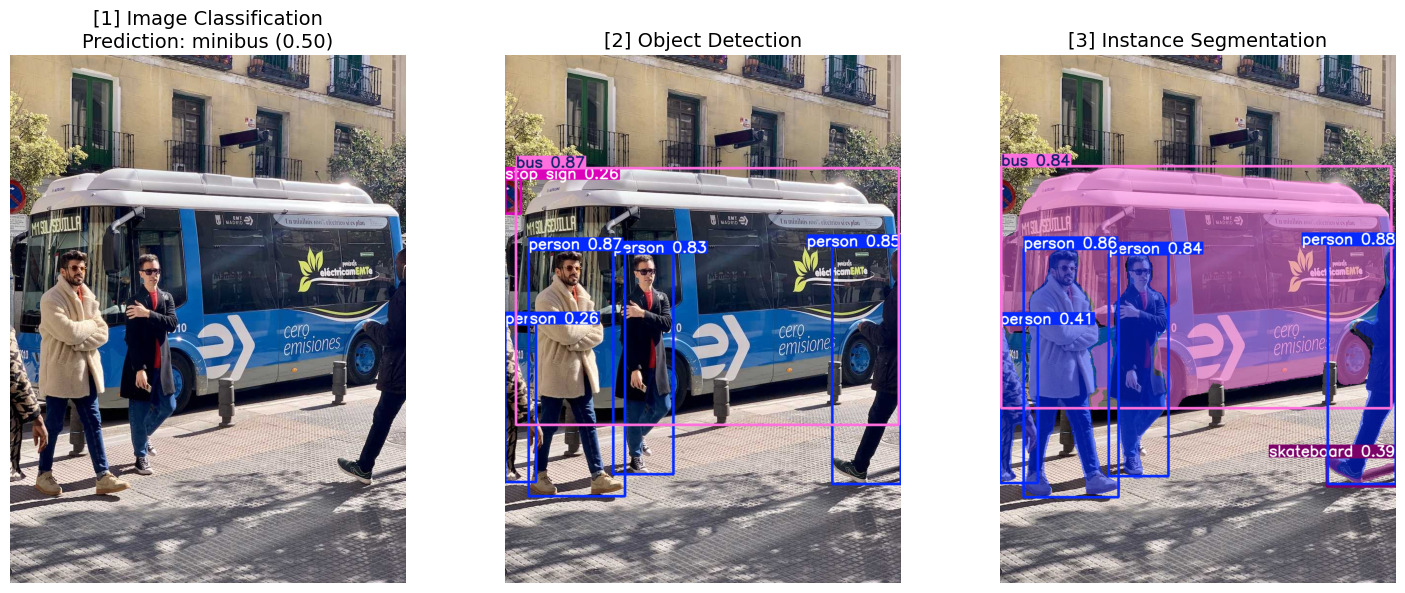

In [3]:
# ==========================================
# 1. 読み込んだサンプル画像で実験
# ==========================================

# 実験結果を描画するキャンバスを設定 (横に3つ並べるため横長に設定)
plt.figure(figsize=(15, 6))

# ==========================================
# 2. 画像分類 (Image Classification)
# 画像全体に何が写っているかを1つのラベルで予測
# ==========================================
print("【1】画像分類を実行中...")
model_cls = YOLO('yolov8n-cls.pt') # 分類用の軽量モデルをロード
results_cls = model_cls(image_path)

# 最も確率の高い予測結果(Top1)を取得
top1_name = results_cls[0].names[results_cls[0].probs.top1]
top1_conf = results_cls[0].probs.top1conf.item()

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"[1] Image Classification\nPrediction: {top1_name} ({top1_conf:.2f})", fontsize=14)
plt.axis('off')

# ==========================================
# 3. 物体認識 (Object Detection)
# 画像内の「どこに」「何が」あるかを四角い枠(バウンディングボックス)で特定
# ==========================================
print("【2】物体認識を実行中...")
model_det = YOLO('yolov8n.pt') # 検出用の軽量モデルをロード
results_det = model_det(image_path)

# 予測結果を画像に描画
res_plotted_det = results_det[0].plot()
res_plotted_det_rgb = cv2.cvtColor(res_plotted_det, cv2.COLOR_BGR2RGB)

plt.subplot(1, 3, 2)
plt.imshow(res_plotted_det_rgb)
plt.title("[2] Object Detection", fontsize=14)
plt.axis('off')

# ==========================================
# 4. セグメンテーション (Instance Segmentation)
# 物体の「輪郭(ピクセル単位)」まで正確に特定し切り出す
# ==========================================
print("【3】セグメンテーションを実行中...")
model_seg = YOLO('yolov8n-seg.pt') # セグメンテーション用の軽量モデルをロード
results_seg = model_seg(image_path)

# 予測結果を画像に描画
res_plotted_seg = results_seg[0].plot()
res_plotted_seg_rgb = cv2.cvtColor(res_plotted_seg, cv2.COLOR_BGR2RGB)

plt.subplot(1, 3, 3)
plt.imshow(res_plotted_seg_rgb)
plt.title("[3] Instance Segmentation", fontsize=14)
plt.axis('off')

# ==========================================
# 5. 結果の表示
# ==========================================
print("処理が完了しました。結果を表示します。")
plt.tight_layout()
plt.show()